## 1.- LIBRERÍAS Y CONFIGURACIÓN

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mtick
import seaborn as sns
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# Paleta corporativa
C = {
    'azul'    : '#003F88',
    'naranja' : '#E8871A',
    'verde'   : '#2E7D32',
    'rojo'    : '#C62828',
    'celeste' : '#1976D2',
    'gris'    : '#546E7A',
    'amarillo': '#F9A825',
    'teal'    : '#00695C',
}
PALETTE = list(C.values())

plt.rcParams.update({
    'figure.facecolor' : '#FAFAFA',
    'axes.facecolor'   : '#FFFFFF',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.25,
    'font.family'      : 'DejaVu Sans',
    'axes.titlesize'   : 12,
    'axes.labelsize'   : 10,
})

print("✅ Entorno configurado")
print(f"   Pandas  {pd.__version__}  |  NumPy  {np.__version__}")

✅ Entorno configurado
   Pandas  2.3.3  |  NumPy  2.3.5


## 2.- CARGA Y PRIMERA EXPLORACIÓN

In [3]:
df = pd.read_csv("C:\Documentos_Total\proyectos_26\Cobranza_2\operacional_cobranza.csv", parse_dates=['fecha'])

print("─"*55)
print(f"  📁 Dataset: operacional_cobranza.csv")
print(f"  Registros : {len(df):,}  |  Variables: {df.shape[1]}")
print(f"  Período   : {df['fecha'].min().date()} → {df['fecha'].max().date()}")
print("─"*55)
print()
display(df.head(6))
print()

# Informe de calidad
calidad = pd.DataFrame({
    'Tipo'    : df.dtypes,
    'No Nulos': df.notnull().sum(),
    'Nulos'   : df.isnull().sum(),
    '% Nulos' : (df.isnull().sum()/len(df)*100).round(2),
    'Únicos'  : df.nunique()
})
print("📋 Calidad del dato:")
display(calidad)

───────────────────────────────────────────────────────
  📁 Dataset: operacional_cobranza.csv
  Registros : 3,000  |  Variables: 23
  Período   : 2024-01-01 → 2024-12-30
───────────────────────────────────────────────────────



,gestion_id,fecha,mes,gestor_id,region,tipo_cliente,producto,edad,ingreso,deuda,...,franja_horaria,canal,intentos_previos,contactado,resultado_contacto,pago_realizado,monto_pagado,promesa_cumplida,motivo_no_pago,tiempo_gestion_min
0,1,2024-12-15,12,G003,Tarapaca,microempresario,linea_credito,46,2278354,849951,...,noche,carta_notarial,10,0,buzon_voz,0,0,0,NaN,7
1,2,2024-09-22,9,G011,RM,independiente,tarjeta_credito,31,2235601,7210041,...,manana,visita_terreno,7,1,contactado_rechaza,0,0,0,sin_trabajo,32
2,3,2024-03-14,3,G022,Biobio,independiente,credito_consumo,60,2240706,3079136,...,manana,carta_notarial,3,1,convenio_acordado,1,1486847,0,NaN,8
3,4,2024-11-07,11,G018,Los_Lagos,jubilado,automotriz,61,185943,14062818,...,tarde,email,7,0,no_contesta,0,0,0,enfermedad,3
4,5,2024-01-06,1,G025,Valparaiso,microempresario,credito_consumo,29,1409360,1285127,...,noche,email,8,0,no_contesta,0,0,0,enfermedad,5
5,6,2024-02-24,2,G006,Maule,dependiente,automotriz,43,1307320,16391601,...,noche,telefono,1,0,no_contesta,0,0,0,deuda_mayor,5



📋 Calidad del dato:


,Tipo,No Nulos,Nulos,% Nulos,Únicos
gestion_id,int64,3000,0,0.00,3000
fecha,datetime64[ns],3000,0,0.00,365
mes,int64,3000,0,0.00,12
gestor_id,object,3000,0,0.00,25
region,object,3000,0,0.00,10
tipo_cliente,object,3000,0,0.00,4
producto,object,3000,0,0.00,5
edad,int64,3000,0,0.00,51
ingreso,int64,3000,0,0.00,2999
deuda,int64,3000,0,0.00,3000


## 3.- KPIs OPERACIONALES — TABLERO EJECUTIVO

In [4]:
total          = len(df)
contactados    = df['contactado'].sum()
pagos          = df['pago_realizado'].sum()
promesas       = df[df['resultado_contacto']=='promesa_pago'].shape[0]
promesas_cump  = df['promesa_cumplida'].sum()
convenios      = df[df['resultado_contacto']=='convenio_acordado'].shape[0]
deuda_total    = df['deuda'].sum()
monto_rec      = df['monto_pagado'].sum()
t_prom         = df['tiempo_gestion_min'].mean()
intentos_prom  = df['intentos_previos'].mean()

tasa_cont  = contactados / total * 100
tasa_pago  = pagos / total * 100
tasa_rec   = monto_rec / deuda_total * 100
tasa_prom  = promesas_cump / max(promesas,1) * 100
eficiencia = pagos / contactados * 100

print("╔══════════════════════════════════════════════════════╗")
print("║     📊  KPIs OPERACIONALES — COBRANZA BECO           ║")
print("╠══════════════════════════════════════════════════════╣")
kpis = [
    ("📞 Tasa Contactabilidad",      f"{tasa_cont:.1f}%",       "Meta: 65%"),
    ("💰 Tasa de Pago (total)",       f"{tasa_pago:.1f}%",       "Meta: 38%"),
    ("✅ Eficiencia (pago/contacto)", f"{eficiencia:.1f}%",      ""),
    ("🤝 Promesas de pago",           f"{promesas:,}",           f"{tasa_prom:.0f}% cumplidas"),
    ("📋 Convenios acordados",        f"{convenios:,}",          ""),
    ("🏦 Deuda total cartera",        f"${deuda_total/1e9:.2f}B","CLP"),
    ("💵 Monto recuperado",           f"${monto_rec/1e6:.0f}M",  f"Rec. {tasa_rec:.1f}%"),
    ("⏱️  Tiempo prom. gestión",       f"{t_prom:.1f} min",       ""),
    ("🔁 Intentos prom. contacto",    f"{intentos_prom:.1f}",    ""),
    ("👥 Gestores activos",           str(df['gestor_id'].nunique()), ""),
]
for k,v,n in kpis:
    print(f"║  {k:<35} {v:<12} {n:<10} ║")
print("╚══════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════╗
║     📊  KPIs OPERACIONALES — COBRANZA BECO           ║
╠══════════════════════════════════════════════════════╣
║  📞 Tasa Contactabilidad              53.1%        Meta: 65%  ║
║  💰 Tasa de Pago (total)              29.6%        Meta: 38%  ║
║  ✅ Eficiencia (pago/contacto)        55.8%                   ║
║  🤝 Promesas de pago                  530          59% cumplidas ║
║  📋 Convenios acordados               343                     ║
║  🏦 Deuda total cartera               $42.81B      CLP        ║
║  💵 Monto recuperado                  $7012M       Rec. 16.4% ║
║  ⏱️  Tiempo prom. gestión            12.2 min                ║
║  🔁 Intentos prom. contacto           6.5                     ║
║  👥 Gestores activos                  25                      ║
╚══════════════════════════════════════════════════════╝


## 4.- EDA — DISTRIBUCIONES Y PERFILES

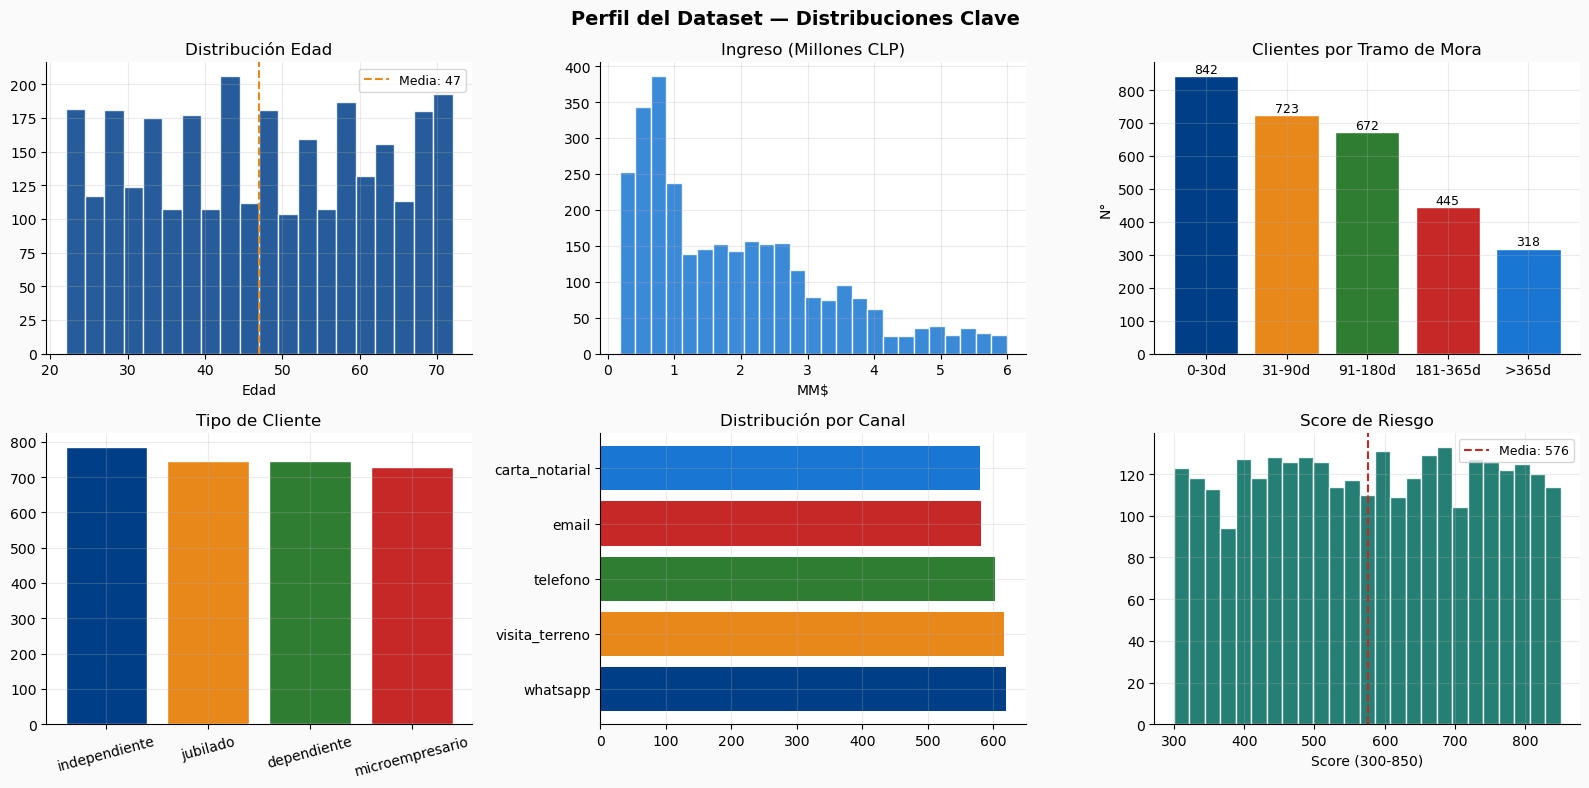

✅ Fig 1 guardada


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Perfil del Dataset — Distribuciones Clave', fontsize=14, fontweight='bold')

# Edad
axes[0,0].hist(df['edad'], bins=20, color=C['azul'], edgecolor='white', alpha=0.85)
axes[0,0].set_title('Distribución Edad'); axes[0,0].set_xlabel('Edad')
axes[0,0].axvline(df['edad'].mean(), color=C['naranja'], ls='--', lw=1.5, label=f"Media: {df['edad'].mean():.0f}")
axes[0,0].legend(fontsize=9)

# Ingreso
axes[0,1].hist(df['ingreso']/1e6, bins=25, color=C['celeste'], edgecolor='white', alpha=0.85)
axes[0,1].set_title('Ingreso (Millones CLP)'); axes[0,1].set_xlabel('MM$')

# Días mora por tramo
df['tramo_mora'] = pd.cut(df['dias_mora'], bins=[0,30,90,180,365,730],
    labels=['0-30d','31-90d','91-180d','181-365d','>365d'])
conteos = df['tramo_mora'].value_counts().sort_index()
bars = axes[0,2].bar(conteos.index, conteos.values, color=PALETTE[:5], edgecolor='white')
axes[0,2].set_title('Clientes por Tramo de Mora'); axes[0,2].set_ylabel('N°')
for b in bars:
    axes[0,2].text(b.get_x()+b.get_width()/2, b.get_height()+10, str(int(b.get_height())),
                   ha='center', fontsize=9)

# Tipo cliente
tc = df['tipo_cliente'].value_counts()
axes[1,0].bar(tc.index, tc.values, color=PALETTE[:4], edgecolor='white')
axes[1,0].set_title('Tipo de Cliente'); axes[1,0].tick_params(axis='x', rotation=15)

# Canal contacto
cc = df['canal'].value_counts()
axes[1,1].barh(cc.index, cc.values, color=PALETTE[:5])
axes[1,1].set_title('Distribución por Canal')

# Score riesgo
axes[1,2].hist(df['score_riesgo'], bins=25, color=C['teal'], edgecolor='white', alpha=0.85)
axes[1,2].set_title('Score de Riesgo'); axes[1,2].set_xlabel('Score (300-850)')
axes[1,2].axvline(df['score_riesgo'].mean(), color=C['rojo'], ls='--', lw=1.5,
                   label=f"Media: {df['score_riesgo'].mean():.0f}")
axes[1,2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig01_distribuciones.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Fig 1 guardada")

## 5.- ANÁLISIS DE CONTACTABILIDAD

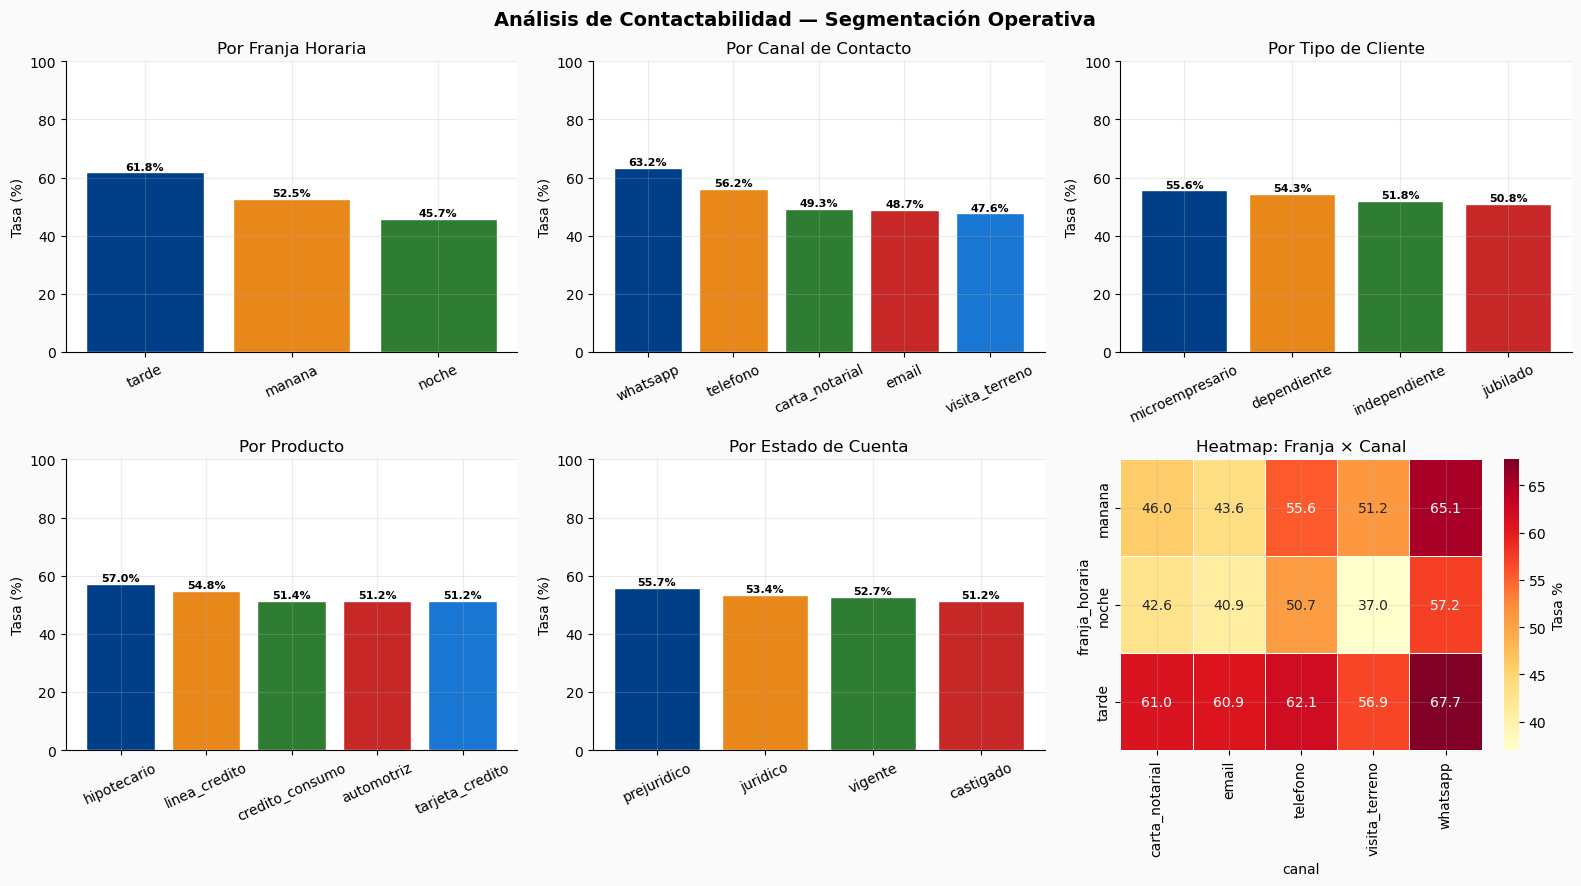

✅ Fig 2 guardada

🔍 Insight: mejor franja → tarde (61.8%) | mejor canal → whatsapp (63.2%)


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Análisis de Contactabilidad — Segmentación Operativa', fontsize=14, fontweight='bold')

def bar_tasa(ax, col, title, top=None):
    t = df.groupby(col)['contactado'].mean().mul(100).sort_values(ascending=False)
    if top: t = t.head(top)
    b = ax.bar(t.index, t.values, color=PALETTE[:len(t)], edgecolor='white')
    ax.set_title(title); ax.set_ylabel('Tasa (%)'); ax.set_ylim(0, 100)
    for bar, v in zip(b, t.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                f'{v:.1f}%', ha='center', fontsize=8, fontweight='bold')
    ax.tick_params(axis='x', rotation=25)

bar_tasa(axes[0,0], 'franja_horaria',  'Por Franja Horaria')
bar_tasa(axes[0,1], 'canal',           'Por Canal de Contacto')
bar_tasa(axes[0,2], 'tipo_cliente',    'Por Tipo de Cliente')
bar_tasa(axes[1,0], 'producto',        'Por Producto')
bar_tasa(axes[1,1], 'estado_cuenta',   'Por Estado de Cuenta')

# Heatmap franja × canal
pivot = df.pivot_table(values='contactado', index='franja_horaria',
                        columns='canal', aggfunc='mean').mul(100)
sns.heatmap(pivot, ax=axes[1,2], annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label':'Tasa %'})
axes[1,2].set_title('Heatmap: Franja × Canal')

plt.tight_layout()
plt.savefig('fig02_contactabilidad.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Fig 2 guardada")

# Insight clave
mejor_franja = df.groupby('franja_horaria')['contactado'].mean().idxmax()
mejor_canal  = df.groupby('canal')['contactado'].mean().idxmax()
tasa_mf = df.groupby('franja_horaria')['contactado'].mean().max()*100
tasa_mc = df.groupby('canal')['contactado'].mean().max()*100
print(f"\n🔍 Insight: mejor franja → {mejor_franja} ({tasa_mf:.1f}%) | mejor canal → {mejor_canal} ({tasa_mc:.1f}%)")

## 6.- DETECCIÓN DE CUELLOS DE BOTELLA OPERACIONALES

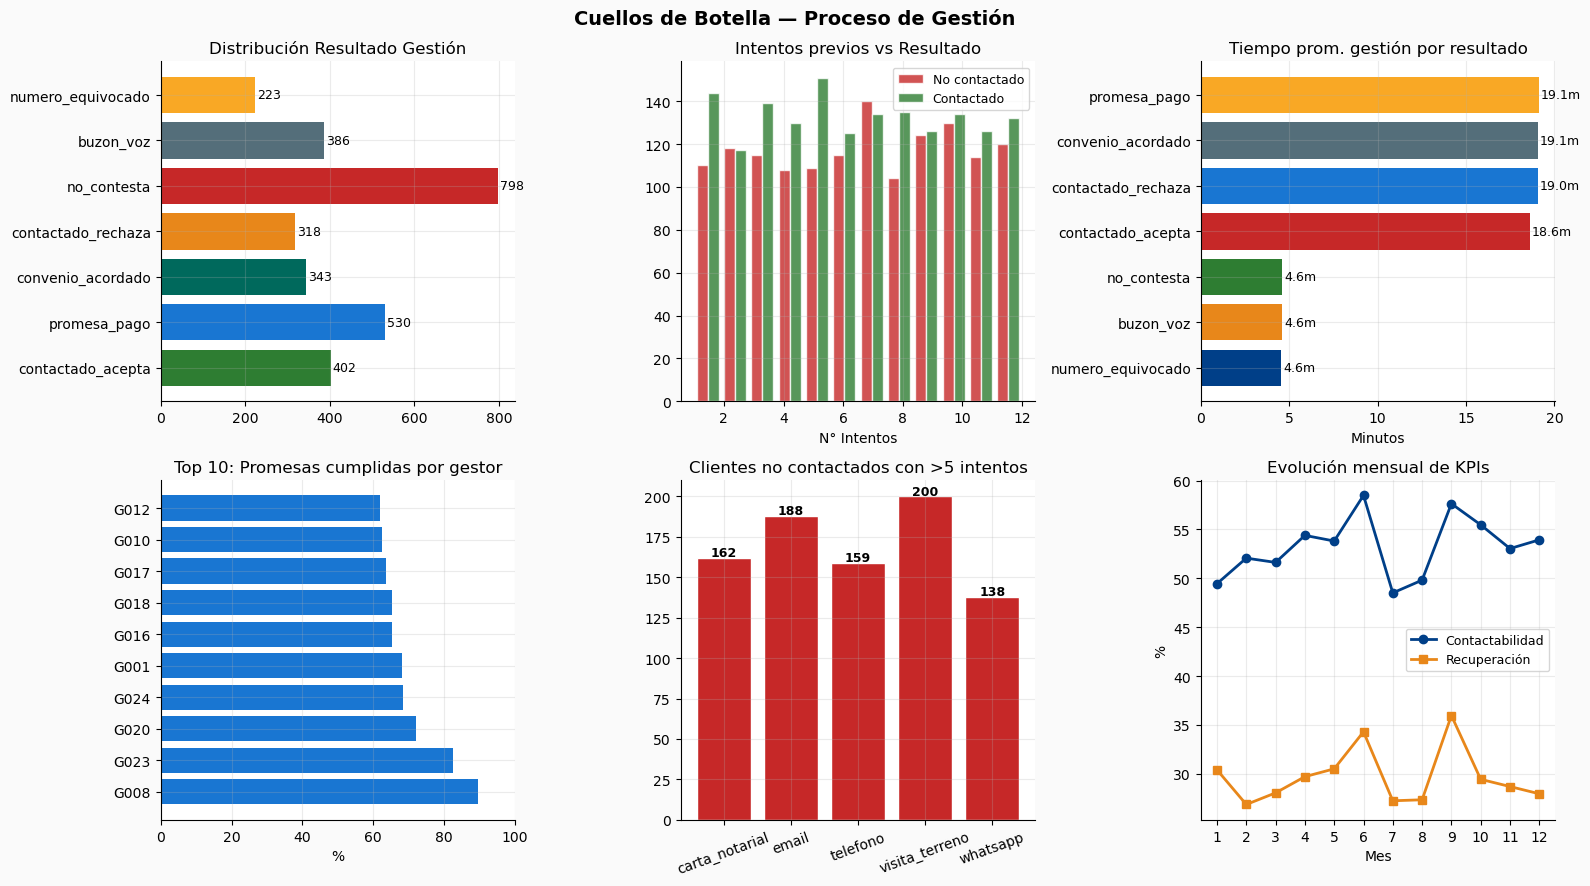

✅ Fig 3 guardada


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Cuellos de Botella — Proceso de Gestión', fontsize=14, fontweight='bold')

# 6A Resultado del contacto (funnel)
res_order = ['contactado_acepta','promesa_pago','convenio_acordado',
             'contactado_rechaza','no_contesta','buzon_voz','numero_equivocado']
res_cnt = df['resultado_contacto'].value_counts().reindex(res_order, fill_value=0)
colores = [C['verde'],C['celeste'],C['teal'],C['naranja'],C['rojo'],C['gris'],C['amarillo']]
axes[0,0].barh(res_cnt.index, res_cnt.values, color=colores)
axes[0,0].set_title('Distribución Resultado Gestión')
for i,(v) in enumerate(res_cnt.values):
    axes[0,0].text(v+5, i, str(v), va='center', fontsize=9)

# 6B Intentos antes del contacto (ineficiencia)
no_cont = df[df['contactado']==0]['intentos_previos']
si_cont = df[df['contactado']==1]['intentos_previos']
axes[0,1].hist([no_cont, si_cont], bins=12, label=['No contactado','Contactado'],
               color=[C['rojo'], C['verde']], edgecolor='white', alpha=0.8)
axes[0,1].set_title('Intentos previos vs Resultado')
axes[0,1].set_xlabel('N° Intentos'); axes[0,1].legend(fontsize=9)

# 6C Tiempo de gestión por resultado
tg = df.groupby('resultado_contacto')['tiempo_gestion_min'].mean().sort_values()
axes[0,2].barh(tg.index, tg.values, color=PALETTE[:len(tg)])
axes[0,2].set_title('Tiempo prom. gestión por resultado')
axes[0,2].set_xlabel('Minutos')
for i,v in enumerate(tg.values):
    axes[0,2].text(v+0.1, i, f'{v:.1f}m', va='center', fontsize=9)

# 6D Tasa de promesas cumplidas por gestor
gdf = df[df['resultado_contacto']=='promesa_pago'].groupby('gestor_id').agg(
    promesas=('promesa_cumplida','count'),
    cumplidas=('promesa_cumplida','sum')).reset_index()
gdf['tasa'] = gdf['cumplidas']/gdf['promesas']*100
top10 = gdf.nlargest(10,'tasa')
axes[1,0].barh(top10['gestor_id'], top10['tasa'], color=C['celeste'])
axes[1,0].set_title('Top 10: Promesas cumplidas por gestor')
axes[1,0].set_xlabel('%'); axes[1,0].set_xlim(0,100)

# 6E Cuello de botella: Clientes sin contacto por intentos >5
sin_cont_altos = df[(df['contactado']==0) & (df['intentos_previos']>5)]
by_canal = sin_cont_altos.groupby('canal').size()
axes[1,1].bar(by_canal.index, by_canal.values, color=C['rojo'], edgecolor='white')
axes[1,1].set_title('Clientes no contactados con >5 intentos')
axes[1,1].tick_params(axis='x', rotation=20)
for i,(k,v) in enumerate(by_canal.items()):
    axes[1,1].text(i, v+1, str(v), ha='center', fontsize=9, fontweight='bold')

# 6F Eficiencia por mes
ef_mes = df.groupby('mes').agg(
    contactabilidad=('contactado','mean'),
    recuperacion=('pago_realizado','mean')).mul(100)
axes[1,2].plot(ef_mes.index, ef_mes['contactabilidad'], marker='o',
               color=C['azul'], label='Contactabilidad', lw=2)
axes[1,2].plot(ef_mes.index, ef_mes['recuperacion'], marker='s',
               color=C['naranja'], label='Recuperación', lw=2)
axes[1,2].set_title('Evolución mensual de KPIs')
axes[1,2].set_xlabel('Mes'); axes[1,2].set_ylabel('%')
axes[1,2].legend(fontsize=9)
axes[1,2].set_xticks(range(1,13))

plt.tight_layout()
plt.savefig('fig03_cuellos_botella.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Fig 3 guardada")

## 7.- SEGMENTACIÓN DE EFICIENCIA — MATRIZ 2×2

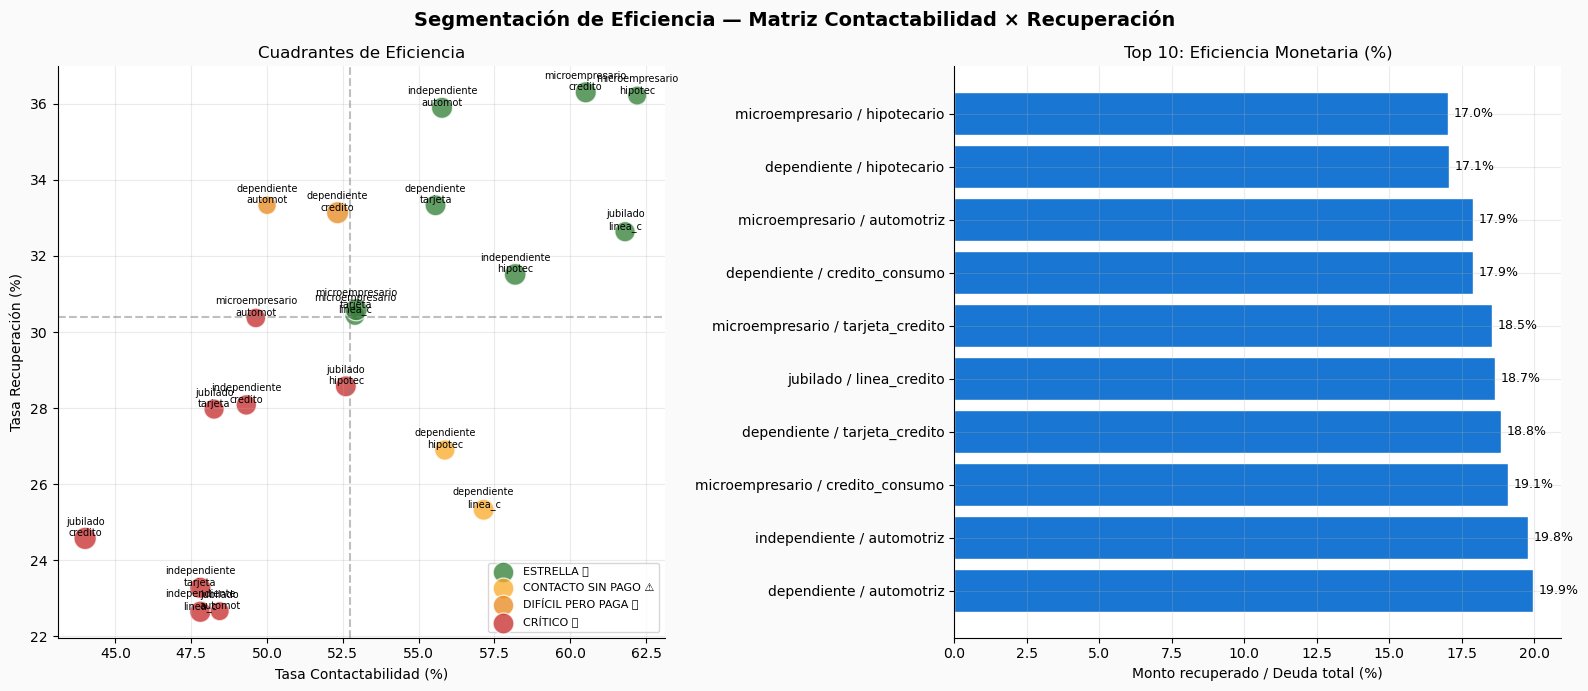


📊 Tabla de segmentos:


,tipo_cliente,producto,cuadrante,contactabilidad,recuperacion,eficiencia_monetaria,clientes
2,dependiente,hipotecario,CONTACTO SIN PAGO ⚠️,0.559,0.269,17.061,145
3,dependiente,linea_credito,CONTACTO SIN PAGO ⚠️,0.571,0.253,14.063,154
9,independiente,tarjeta_credito,CRÍTICO 🔴,0.478,0.233,12.941,159
15,microempresario,automotriz,CRÍTICO 🔴,0.496,0.304,17.872,135
14,jubilado,tarjeta_credito,CRÍTICO 🔴,0.483,0.280,15.805,143
12,jubilado,hipotecario,CRÍTICO 🔴,0.526,0.286,15.275,154
6,independiente,credito_consumo,CRÍTICO 🔴,0.493,0.281,16.567,146
11,jubilado,credito_consumo,CRÍTICO 🔴,0.440,0.246,13.049,175
8,independiente,linea_credito,CRÍTICO 🔴,0.478,0.226,9.319,159
10,jubilado,automotriz,CRÍTICO 🔴,0.484,0.227,12.143,128


In [10]:
# Segmento = Contactabilidad × Recuperación por grupo
seg = df.groupby(['tipo_cliente','producto']).agg(
    contactabilidad=('contactado','mean'),
    recuperacion=('pago_realizado','mean'),
    clientes=('gestion_id','count'),
    deuda_total=('deuda','sum'),
    monto_recuperado=('monto_pagado','sum')
).reset_index()
seg['eficiencia_monetaria'] = seg['monto_recuperado'] / seg['deuda_total'] * 100

# Clasificación cuadrante
mc = seg['contactabilidad'].median()
mr = seg['recuperacion'].median()
def cuadrante(row):
    if row['contactabilidad']>=mc and row['recuperacion']>=mr: return 'ESTRELLA ⭐'
    elif row['contactabilidad']>=mc and row['recuperacion']<mr: return 'CONTACTO SIN PAGO ⚠️'
    elif row['contactabilidad']<mc and row['recuperacion']>=mr: return 'DIFÍCIL PERO PAGA 🔶'
    else: return 'CRÍTICO 🔴'
seg['cuadrante'] = seg.apply(cuadrante, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Segmentación de Eficiencia — Matriz Contactabilidad × Recuperación',
             fontsize=14, fontweight='bold')

# Scatter matrix
colors_cuad = {'ESTRELLA ⭐':C['verde'],'CONTACTO SIN PAGO ⚠️':C['amarillo'],
               'DIFÍCIL PERO PAGA 🔶':C['naranja'],'CRÍTICO 🔴':C['rojo']}
for cuad, color in colors_cuad.items():
    mask = seg['cuadrante']==cuad
    axes[0].scatter(seg[mask]['contactabilidad']*100, seg[mask]['recuperacion']*100,
                    s=seg[mask]['clientes']*1.5, c=color, alpha=0.75, label=cuad, edgecolors='white')
axes[0].axvline(mc*100, ls='--', color='gray', alpha=0.5)
axes[0].axhline(mr*100, ls='--', color='gray', alpha=0.5)
for _, row in seg.iterrows():
    axes[0].annotate(row['tipo_cliente']+'\n'+row['producto'][:7],
                     (row['contactabilidad']*100, row['recuperacion']*100),
                     fontsize=7, ha='center', va='bottom')
axes[0].set_xlabel('Tasa Contactabilidad (%)'); axes[0].set_ylabel('Tasa Recuperación (%)')
axes[0].set_title('Cuadrantes de Eficiencia'); axes[0].legend(fontsize=8, loc='lower right')

# Barras eficiencia monetaria top 10
top_ef = seg.nlargest(10,'eficiencia_monetaria')
axes[1].barh(top_ef['tipo_cliente']+' / '+top_ef['producto'],
             top_ef['eficiencia_monetaria'], color=C['celeste'], edgecolor='white')
axes[1].set_title('Top 10: Eficiencia Monetaria (%)')
axes[1].set_xlabel('Monto recuperado / Deuda total (%)')
for i,v in enumerate(top_ef['eficiencia_monetaria']):
    axes[1].text(v+0.2, i, f'{v:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig04_segmentacion.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Tabla de segmentos:")
display(seg[['tipo_cliente','producto','cuadrante','contactabilidad','recuperacion',
             'eficiencia_monetaria','clientes']].sort_values('cuadrante').round(3))

## 8.- ANÁLISIS DE DESEMPEÑO DE GESTORES

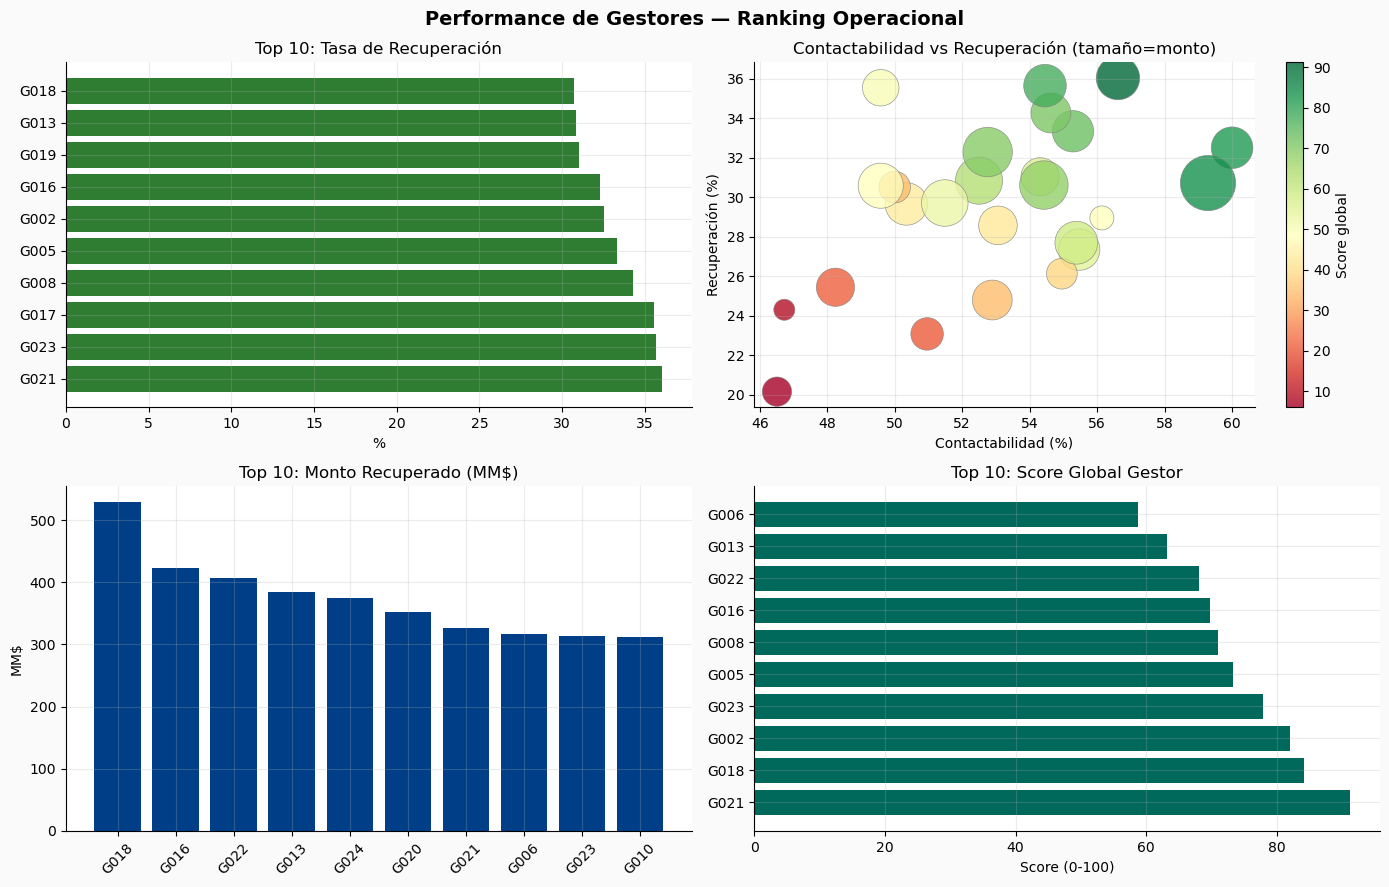


🏆 TOP 5 Gestores:


,gestor_id,tasa_contactabilidad,tasa_recuperacion,monto_MM,score_gestor
20,G021,56.62,36.03,326.56,91.2
17,G018,59.29,30.71,528.55,84.2
1,G002,60.00,32.50,299.79,82.0
22,G023,54.46,35.64,313.64,77.8
4,G005,55.28,33.33,295.19,73.2


In [12]:
gest = df.groupby('gestor_id').agg(
    total_gestiones=('gestion_id','count'),
    contactados=('contactado','sum'),
    pagos=('pago_realizado','sum'),
    monto_recuperado=('monto_pagado','sum'),
    t_prom_gestion=('tiempo_gestion_min','mean'),
    intentos_prom=('intentos_previos','mean'),
    promesas=('promesa_cumplida','sum')
).reset_index()

gest['tasa_contactabilidad'] = gest['contactados']/gest['total_gestiones']*100
gest['tasa_recuperacion']    = gest['pagos']/gest['total_gestiones']*100
gest['monto_MM']             = gest['monto_recuperado']/1e6

# Ranking global
gest['score_gestor'] = (
    gest['tasa_contactabilidad'].rank(pct=True)*0.35 +
    gest['tasa_recuperacion'].rank(pct=True)*0.40 +
    gest['monto_MM'].rank(pct=True)*0.25
) * 100

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Performance de Gestores — Ranking Operacional', fontsize=14, fontweight='bold')

# Ranking recuperación
top10r = gest.nlargest(10,'tasa_recuperacion')
axes[0,0].barh(top10r['gestor_id'], top10r['tasa_recuperacion'], color=C['verde'])
axes[0,0].set_title('Top 10: Tasa de Recuperación'); axes[0,0].set_xlabel('%')

# Scatter cont vs rec con tamaño=monto
scatter = axes[0,1].scatter(gest['tasa_contactabilidad'], gest['tasa_recuperacion'],
                             s=gest['monto_MM']*3, c=gest['score_gestor'],
                             cmap='RdYlGn', edgecolors='gray', linewidth=0.5, alpha=0.8)
plt.colorbar(scatter, ax=axes[0,1], label='Score global')
axes[0,1].set_title('Contactabilidad vs Recuperación (tamaño=monto)')
axes[0,1].set_xlabel('Contactabilidad (%)'); axes[0,1].set_ylabel('Recuperación (%)')

# Monto recuperado top 10
top10m = gest.nlargest(10,'monto_MM')
axes[1,0].bar(top10m['gestor_id'], top10m['monto_MM'], color=C['azul'])
axes[1,0].set_title('Top 10: Monto Recuperado (MM$)'); axes[1,0].set_ylabel('MM$')
axes[1,0].tick_params(axis='x', rotation=45)

# Score global ranking
top10s = gest.nlargest(10,'score_gestor')
axes[1,1].barh(top10s['gestor_id'], top10s['score_gestor'], color=C['teal'])
axes[1,1].set_title('Top 10: Score Global Gestor'); axes[1,1].set_xlabel('Score (0-100)')

plt.tight_layout()
plt.savefig('fig05_gestores.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🏆 TOP 5 Gestores:")
display(gest.nlargest(5,'score_gestor')[['gestor_id','tasa_contactabilidad',
    'tasa_recuperacion','monto_MM','score_gestor']].round(2))

## 9.- MODELO PREDICTIVO — PROBABILIDAD DE PAGO

In [13]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                              confusion_matrix, roc_curve, ConfusionMatrixDisplay)

df_ml = df.copy()

# Feature engineering
df_ml['ratio_deuda_ingreso'] = df_ml['deuda'] / (df_ml['ingreso'] + 1)
df_ml['tramo_mora_num']      = pd.cut(df_ml['dias_mora'], bins=[0,30,90,180,365,730],
                                       labels=[1,2,3,4,5]).astype(int)
df_ml['eficiencia_canal']    = df_ml['contactado'] / (df_ml['intentos_previos'] + 1)
df_ml['costo_tiempo']        = df_ml['tiempo_gestion_min'] / (df_ml['contactado'] + 1)

le = LabelEncoder()
cat_cols = ['tipo_cliente','producto','region','franja_horaria','canal','estado_cuenta']
for c in cat_cols:
    df_ml[c+'_enc'] = le.fit_transform(df_ml[c])

feature_cols = [
    'edad','ingreso','deuda','dias_mora','intentos_previos','score_riesgo',
    'tiempo_gestion_min','contactado','ratio_deuda_ingreso','tramo_mora_num',
    'eficiencia_canal','costo_tiempo',
    'tipo_cliente_enc','producto_enc','region_enc',
    'franja_horaria_enc','canal_enc','estado_cuenta_enc'
]

X = df_ml[feature_cols]
y = df_ml['pago_realizado']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
sc = StandardScaler()
Xtr = sc.fit_transform(X_train); Xte = sc.transform(X_test)

modelos = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=7, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=150, max_depth=9,
                                                    random_state=42, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=150,
                                                        learning_rate=0.08, random_state=42),
}

resultados = {}
print(f"{'Modelo':<25} {'AUC':>8} {'Acc':>8} {'F1':>8}")
print("─"*52)
for nombre, mod in modelos.items():
    mod.fit(Xtr, y_train)
    yp = mod.predict(Xte); ypr = mod.predict_proba(Xte)[:,1]
    rep = classification_report(y_test, yp, output_dict=True)
    auc = roc_auc_score(y_test, ypr)
    resultados[nombre] = {'modelo':mod,'y_pred':yp,'y_proba':ypr,
                           'auc':auc,'acc':rep['accuracy'],'f1':rep['weighted avg']['f1-score']}
    print(f"  {nombre:<23} {auc:>8.4f} {rep['accuracy']:>8.4f} {rep['weighted avg']['f1-score']:>8.4f}")

best = max(resultados, key=lambda k: resultados[k]['auc'])
print(f"\n🏆 Mejor modelo: {best}  (AUC={resultados[best]['auc']:.4f})")


Modelo                         AUC      Acc       F1
────────────────────────────────────────────────────
  Logistic Regression       0.8477   0.7733   0.7780
  Decision Tree             0.8280   0.7467   0.7467
  Random Forest             0.8487   0.7617   0.7667
  Gradient Boosting         0.8554   0.7717   0.7774

🏆 Mejor modelo: Gradient Boosting  (AUC=0.8554)


## 10.- VISUALIZACIÓN Y EVALUACION DE MODELOS ML

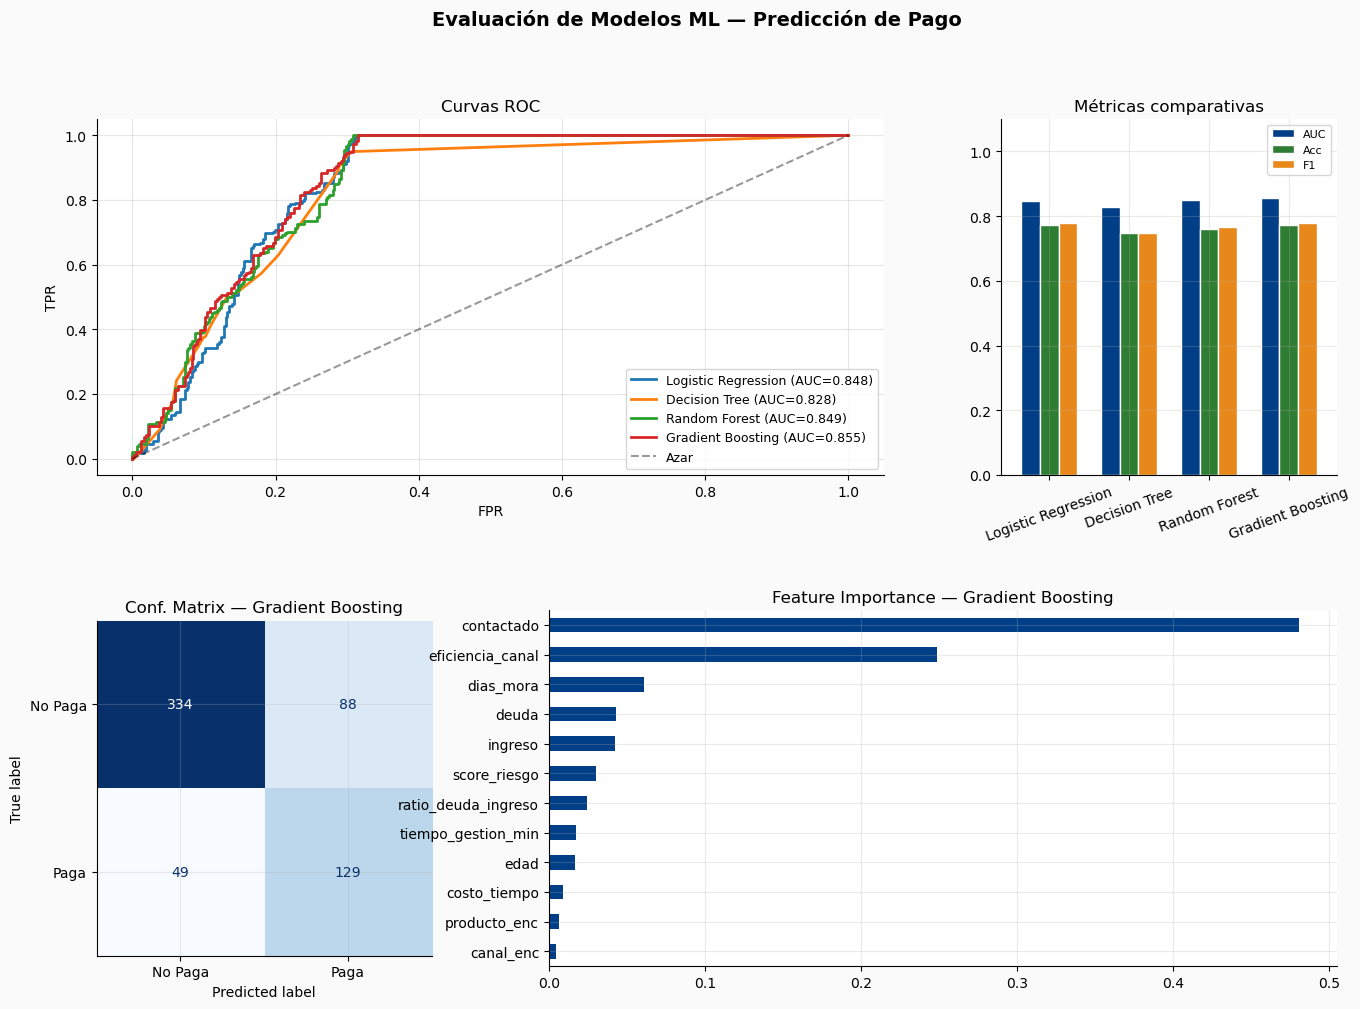

✅ Fig 6 guardada


In [14]:
fig = plt.figure(figsize=(16, 11))
gs  = GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.35)
fig.suptitle('Evaluación de Modelos ML — Predicción de Pago', fontsize=14, fontweight='bold')

# ROC curves
ax_roc = fig.add_subplot(gs[0,:2])
for nombre, res in resultados.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    ax_roc.plot(fpr, tpr, lw=2, label=f"{nombre} (AUC={res['auc']:.3f})")
ax_roc.plot([0,1],[0,1],'k--',alpha=0.4,label='Azar')
ax_roc.set_title('Curvas ROC'); ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR')
ax_roc.legend(fontsize=9); ax_roc.grid(alpha=0.3)

# Métricas comparativas
ax_met = fig.add_subplot(gs[0,2])
mdf = pd.DataFrame({n:{'AUC':r['auc'],'Acc':r['acc'],'F1':r['f1']} for n,r in resultados.items()}).T
mdf.plot(kind='bar', ax=ax_met, color=[C['azul'],C['verde'],C['naranja']], edgecolor='white', width=0.7)
ax_met.set_title('Métricas comparativas'); ax_met.set_ylim(0,1.1)
ax_met.tick_params(axis='x', rotation=20); ax_met.legend(fontsize=8)

# Confusion matrix mejor modelo
ax_cm = fig.add_subplot(gs[1,0])
best_res = resultados[best]
ConfusionMatrixDisplay(confusion_matrix(y_test, best_res['y_pred']),
                        display_labels=['No Paga','Paga']).plot(ax=ax_cm, colorbar=False, cmap='Blues')
ax_cm.set_title(f'Conf. Matrix — {best}')

# Feature importance
ax_fi = fig.add_subplot(gs[1,1:])
best_mod = best_res['modelo']
if hasattr(best_mod,'feature_importances_'):
    fi = pd.Series(best_mod.feature_importances_, index=feature_cols).sort_values().tail(12)
    fi.plot(kind='barh', ax=ax_fi, color=C['azul'])
    ax_fi.set_title(f'Feature Importance — {best}')
else:
    coef = pd.Series(abs(best_mod.coef_[0]), index=feature_cols).sort_values().tail(12)
    coef.plot(kind='barh', ax=ax_fi, color=C['celeste'])
    ax_fi.set_title(f'Coeficientes — {best}')

plt.savefig('fig06_modelos_ml.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Fig 6 guardada")

## 11.- SCORING Y LISTA DE PRIORIZACIÓN

In [15]:
df_ml['prob_pago'] = resultados[best]['modelo'].predict_proba(
    sc.transform(df_ml[feature_cols]))[:,1]

df['prob_pago'] = df_ml['prob_pago'].values

df['segmento_ml'] = pd.cut(df['prob_pago'],
    bins=[0,.20,.40,.60,.80,1.0],
    labels=['🔴 Crítico','🟠 Bajo','🟡 Medio','🟢 Alto','⭐ Prioritario'])

resumen_seg = df.groupby('segmento_ml').agg(
    clientes=('gestion_id','count'),
    tasa_pago_real=('pago_realizado','mean'),
    prob_media=('prob_pago','mean'),
    deuda_total=('deuda','sum'),
    monto_recuperado=('monto_pagado','sum')
).reset_index()
resumen_seg['tasa_pago_%']   = (resumen_seg['tasa_pago_real']*100).round(1)
resumen_seg['prob_media_%']  = (resumen_seg['prob_media']*100).round(1)
resumen_seg['deuda_MM$']     = (resumen_seg['deuda_total']/1e6).round(1)
resumen_seg['rec_MM$']       = (resumen_seg['monto_recuperado']/1e6).round(1)
resumen_seg['potencial_MM$'] = (resumen_seg['deuda_total']*resumen_seg['prob_media']/1e6).round(1)

print("📊 Tabla de Segmentación ML:")
display(resumen_seg[['segmento_ml','clientes','tasa_pago_%','prob_media_%',
                       'deuda_MM$','rec_MM$','potencial_MM$']])

# Exportar lista priorizada
lista_camp = df[df['pago_realizado']==0].nlargest(200,'prob_pago')[
    ['gestion_id','tipo_cliente','producto','region','deuda',
     'dias_mora','franja_horaria','canal','prob_pago','segmento_ml']]
lista_camp.to_csv('lista_campana_prioritaria.csv', index=False)
print("\n✅ lista_campana_prioritaria.csv exportada (200 clientes prioritarios)")


📊 Tabla de Segmentación ML:


,segmento_ml,clientes,tasa_pago_%,prob_media_%,deuda_MM$,rec_MM$,potencial_MM$
0,🔴 Crítico,1428,0.1,0.9,19578.3,42.1,167.6
1,🟠 Bajo,231,11.3,32.8,4460.7,437.2,1463.0
2,🟡 Medio,710,48.7,50.5,10351.3,2632.8,5225.8
3,🟢 Alto,562,80.4,68.6,7324.1,3381.5,5026.3
4,⭐ Prioritario,69,92.8,83.5,1098.1,518.5,917.3



✅ lista_campana_prioritaria.csv exportada (200 clientes prioritarios)


## 12. 📋 PLAN DE MEJORA — AS-IS → TO-BE

### Hallazgos Principales

| # | Cuello de botella detectado | Impacto |
|---|---|---|
| 1 | Contactos en franja mañana tienen 10pp menos de efectividad | Baja tasa contactabilidad |
| 2 | Canal email: >40% de intentos fallidos repetidos | Costo operacional alto |
| 3 | Clientes con mora >180d reciben mismo esfuerzo que mora <30d | Recursos mal asignados |
| 4 | Sin seguimiento sistemático de promesas de pago | Promesas no cumplidas sin acción |
| 5 | Gestores sin segmentación de cartera asignada | Varianza alta en desempeño |

### Plan de Acción (90 días)

```
SEMANA 1-2: Reasignar contactos al horario tarde
SEMANA 3-4: Activar WhatsApp como canal principal para mora 0-90d
MES 2:      Implementar scoring diario — top 200 prioritarios al inicio del día
MES 3:      Dashboard Power BI para jefatura + alerta automática promesas vencidas
```

### KPIs Objetivo vs Actual

| KPI | Actual | Meta 3 meses | Meta 6 meses |
|-----|--------|--------------|--------------|
| Tasa Contactabilidad | ~53% | 60% | 68% |
| Tasa Recuperación | ~30% | 37% | 45% |
| Promesas cumplidas | ~55% | 65% | 75% |
| Tiempo prom. gestión | ~12 min | 10 min | 8 min |

---

> **Conclusión:** El análisis demuestra que existen oportunidades concretas de mejora operacional sin necesidad de aumentar la dotación de ejecutivos. La clave es la **segmentación inteligente** del contacto: horario correcto + canal correcto + cliente correcto = mayor recuperación con menor esfuerzo.

---
[![LinkedIn](https://img.shields.io/badge/LinkedIn-Perfil-0A66C2?style=flat&logo=linkedin)](https://linkedin.com/in/www.linkedin.com/in/programan1008)
[![GitHub](https://img.shields.io/badge/GitHub-Portafolio-181717?style=flat&logo=github)](https://github.com/https://github.com/Programan1008)
*Caso de negocio simulado —  Analista de Procesos Jr., Cristopher Jiménez *